# Idea 12: Category-Customer Affinity Stability

## 1. Hypothesis and Setup

**Question:** Is a customer's category preference stable over time, or does it drift significantly?

**Hypothesis:** Customers maintain consistent category preferences across two time periods,
making category affinity a reliable signal for personalized ranking.

**Datasets:**
- `transaction_full_2025.parquet`
- `items.parquet`

**Columns:** `customer_id`, `item_id`, `updated_date`, `quantity`, `category_l1`, `category_l2`

**Method:**
1. Split each customer's history into two equal time halves (by date).
2. Compute category share distribution per period.
3. Calculate Spearman & Kendall-tau rank correlations between periods.
4. Measure category churn rate (% of top-5 cats in P1 absent from top-5 in P2).
5. Compute KL divergence of category distributions between periods.
6. Visualize stability patterns.

**Decision Rule:** KEEP if median rank correlation > 0.6 OR category churn rate < 20%.

In [12]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

DATA_DIR = Path('../..')
TXN_FILE  = DATA_DIR / 'transaction_full_2025.parquet'
ITEMS_FILE = DATA_DIR / 'items.parquet'
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load & Join Data

In [13]:
items = (
    pl.scan_parquet(ITEMS_FILE)
    .select(['item_id','category_l1','category_l2'])
)

txn = (
    pl.scan_parquet(TXN_FILE)
    .select(['customer_id','item_id','updated_date','quantity'])
    .with_columns(pl.col('updated_date').dt.truncate('1d').alias('date'))
    .join(items, on='item_id', how='left')
    .collect()
)

print(f'Total transactions: {len(txn):,}')
print(f'Unique customers  : {txn["customer_id"].n_unique():,}')
print(f'Date range        : {txn["date"].min()} → {txn["date"].max()}')
print(f'Schema: {txn.schema}')

Total transactions: 37,684,823
Unique customers  : 2,821,898
Date range        : 2025-01-01 00:00:00 → 2025-12-01 00:00:00
Schema: Schema({'customer_id': Int32, 'item_id': String, 'updated_date': Datetime(time_unit='us', time_zone=None), 'quantity': Int32, 'date': Datetime(time_unit='us', time_zone=None), 'category_l1': String, 'category_l2': String})


## 3. Split Each Customer's History into Two Equal Halves

In [14]:
# ── Step 1: compute per-customer date range ──────────────────────────────
cust_dates = (
    txn
    .group_by('customer_id')
    .agg([
        pl.col('date').min().alias('first_date'),
        pl.col('date').max().alias('last_date'),
        pl.col('date').n_unique().alias('active_days'),
    ])
)
print(f'Total unique customers: {len(cust_dates):,}')
print(f'Customers with active_days >= 2: {cust_dates.filter(pl.col("active_days") >= 2).height:,}')
print(f'Customers with active_days >= 4: {cust_dates.filter(pl.col("active_days") >= 4).height:,}')
print('Sample cust_dates:')
print(cust_dates.filter(pl.col('active_days') >= 4).head(3))

# ── Step 2: compute mid_date via timestamp integer arithmetic ─────────────
# Cast Int64 microseconds back to Datetime — more portable than pl.from_epoch
cust_dates = (
    cust_dates
    .filter(pl.col('first_date') < pl.col('last_date'))   # exclude single-day customers
    .with_columns(
        (
            (
                pl.col('first_date').dt.timestamp('us')
                + pl.col('last_date').dt.timestamp('us')
            ) // 2
        ).cast(pl.Datetime('us')).alias('mid_date')
    )
)
print(f'Customers with first_date < last_date: {len(cust_dates):,}')
print('Sample mid_date values:')
print(cust_dates.select(['customer_id','first_date','mid_date','last_date']).head(3))

# ── Step 3: assign P1/P2 ─────────────────────────────────────────────────
txn_split = (
    txn
    .join(cust_dates.select(['customer_id', 'mid_date']), on='customer_id', how='inner')
    .with_columns(
        pl.when(pl.col('date') <= pl.col('mid_date'))
          .then(pl.lit('P1'))
          .otherwise(pl.lit('P2'))
          .alias('period')
    )
)
print(f'Transactions after inner-join: {len(txn_split):,}')
print('Period counts:')
print(txn_split.group_by('period').agg(pl.len().alias('n')))

# ── Step 4: active days per (customer, period) ────────────────────────────
period_activity = (
    txn_split
    .group_by(['customer_id', 'period'])
    .agg(
        pl.col('date').n_unique().alias('active_days'),
        pl.col('quantity').sum().alias('total_qty'),
    )
)
print('Active days per period distribution:')
print(period_activity.select('active_days').describe())

# ── Step 5: qualify customers — RELAXED to ≥1 active day per period ───────
# (original ≥2 was too strict for a 332-day dataset with sparse buyers)
valid_custs = (
    period_activity
    .filter(pl.col('active_days') >= 1)   # relaxed from ≥2
    .group_by('customer_id')
    .agg(pl.col('period').n_unique().alias('n_periods'))
    .filter(pl.col('n_periods') == 2)
    .select('customer_id')
)

txn_valid = txn_split.join(valid_custs, on='customer_id', how='inner')
n_valid = txn_valid['customer_id'].n_unique()
print(f'Qualifying customers (≥1 active day each period): {n_valid:,}')
print(f'Transactions in analysis set: {len(txn_valid):,}')

Total unique customers: 2,821,898
Customers with active_days >= 2: 1,496,363
Customers with active_days >= 4: 888,892
Sample cust_dates:
shape: (3, 4)
┌─────────────┬─────────────────────┬─────────────────────┬─────────────┐
│ customer_id ┆ first_date          ┆ last_date           ┆ active_days │
│ ---         ┆ ---                 ┆ ---                 ┆ ---         │
│ i32         ┆ datetime[μs]        ┆ datetime[μs]        ┆ u32         │
╞═════════════╪═════════════════════╪═════════════════════╪═════════════╡
│ 8104549     ┆ 2025-02-10 00:00:00 ┆ 2025-11-22 00:00:00 ┆ 12          │
│ 8982137     ┆ 2025-07-26 00:00:00 ┆ 2025-10-06 00:00:00 ┆ 5           │
│ 9156341     ┆ 2025-09-04 00:00:00 ┆ 2025-10-30 00:00:00 ┆ 6           │
└─────────────┴─────────────────────┴─────────────────────┴─────────────┘
Customers with first_date < last_date: 1,496,363
Sample mid_date values:
shape: (3, 4)
┌─────────────┬─────────────────────┬─────────────────────┬─────────────────────┐
│ customer_id 

## 4. Category Share Distributions per Period

In [15]:
# Aggregate purchases by (customer, period, category_l2)
cat_counts = (
    txn_valid
    .filter(pl.col('category_l2').is_not_null())
    .group_by(['customer_id','period','category_l2'])
    .agg(pl.col('quantity').sum().alias('qty'))
)

# Compute category share within each customer-period
cat_shares = (
    cat_counts
    .with_columns(
        (pl.col('qty') / pl.col('qty').sum().over(['customer_id','period'])).alias('share')
    )
)

# Pivot to wide: one row per (customer, category), P1 share and P2 share
# Aggregate purchases by (customer, period, category_l2)
cat_counts = (
    txn_valid
    .filter(pl.col('category_l2').is_not_null())
    .group_by(['customer_id', 'period', 'category_l2'])
    .agg(pl.col('quantity').sum().alias('qty'))
)

# Compute category share within each customer-period
cat_shares = (
    cat_counts
    .with_columns(
        (pl.col('qty') / pl.col('qty').sum().over(['customer_id', 'period'])).alias('share')
    )
)

# Pivot to wide: one row per (customer, category), P1 share and P2 share
wide = (
    cat_shares
    .pivot(
        on="period", 
        index=["customer_id", "category_l2"], 
        values="share"
    )
    .rename({"P1": "share_p1", "P2": "share_p2"})
    .fill_null(0.0)
)

print(f'Wide table rows (customer × category pairs): {len(wide):,}')
print(wide.head(5))

Wide table rows (customer × category pairs): 12,000,222
shape: (5, 4)
┌─────────────┬───────────────────────────┬──────────┬──────────┐
│ customer_id ┆ category_l2               ┆ share_p1 ┆ share_p2 │
│ ---         ┆ ---                       ┆ ---      ┆ ---      │
│ f64         ┆ str                       ┆ f64      ┆ f64      │
╞═════════════╪═══════════════════════════╪══════════╪══════════╡
│ 8.368758e6  ┆ Huggies                   ┆ 0.032258 ┆ 0.038462 │
│ 8.114747e6  ┆ Bobby                     ┆ 1.0      ┆ 0.5      │
│ 2.339466e6  ┆ Thiết bị điện gia dụng    ┆ 0.010638 ┆ 0.00578  │
│ 1.290467e6  ┆ TP từ sữa (bảo quản lạnh) ┆ 0.111111 ┆ 0.031915 │
│ 7.228054e6  ┆ TPCN cho bé               ┆ 0.111111 ┆ 0.0      │
└─────────────┴───────────────────────────┴──────────┴──────────┘


## 5. Rank-Order Correlations (Spearman & Kendall-Tau)

In [25]:
from scipy.stats import kendalltau

# 1. Filter
filtered_wide = wide.filter(pl.len().over("customer_id") >= 2)

# 2. GroupBy, Aggregate into Lists, THEN Calculate
corr_df = (
    filtered_wide.group_by("customer_id")
    .agg(
        # Native Polars Spearman (happens safely inside agg)
        spearman=pl.corr("share_p1", "share_p2", method="spearman"),
        
        # Bundle the pairs into lists for Scipy
        p1_list=pl.col("share_p1"),
        p2_list=pl.col("share_p2")
    )
    .with_columns(
        # NOW we map over the nicely bundled lists row-by-row in the new dataframe
        kendall=pl.struct(["p1_list", "p2_list"]).map_elements(
            lambda cols: (
                kendalltau(cols["p1_list"], cols["p2_list"])[0] 
                if len(cols["p1_list"]) >= 2 else None
            ),
            return_dtype=pl.Float64
        )
    )
    # Clean up the temporary list columns so your dataframe stays neat
    .drop(["p1_list", "p2_list"])
)
# 3. Calculate summary statistics
# First, filter out the rows where correlation resulted in a mathematical NaN
valid_corrs = corr_df.filter(
    ~pl.col("spearman").is_nan() & 
    ~pl.col("kendall").is_nan()
)

# Now calculate your stats on the clean subset
sp_median = valid_corrs['spearman'].drop_nulls().median()
sp_mean   = valid_corrs['spearman'].drop_nulls().mean()
sp_std    = valid_corrs['spearman'].drop_nulls().std()
kt_median = valid_corrs['kendall'].drop_nulls().median()

# Let's also see exactly how many undefined correlations there were
nan_count = len(corr_df) - len(valid_corrs)

print(f'Total customers: {len(corr_df):,}')
print(f'Customers with undefined (NaN) correlations dropped: {nan_count:,}')
print(f'Customers with valid correlations: {len(valid_corrs):,}')
print(f'-'*40)
print(f'Spearman ρ  — median: {sp_median:.3f}, mean: {sp_mean:.3f}, std: {sp_std:.3f}')
print(f'Kendall τ   — median: {kt_median:.3f}')

print(f'\nCorrelation distribution (Cleaned):')
print(valid_corrs.describe())

Total customers: 1,380,788
Customers with undefined (NaN) correlations dropped: 52,097
Customers with valid correlations: 1,328,691
----------------------------------------
Spearman ρ  — median: -0.440, mean: -0.329, std: 0.589
Kendall τ   — median: -0.381

Correlation distribution (Cleaned):
shape: (9, 4)
┌────────────┬─────────────┬────────────┬────────────┐
│ statistic  ┆ customer_id ┆ spearman   ┆ kendall    │
│ ---        ┆ ---         ┆ ---        ┆ ---        │
│ str        ┆ f64         ┆ f64        ┆ f64        │
╞════════════╪═════════════╪════════════╪════════════╡
│ count      ┆ 1.328691e6  ┆ 1.328691e6 ┆ 1.328691e6 │
│ null_count ┆ 0.0         ┆ 0.0        ┆ 0.0        │
│ mean       ┆ 6.1050e6    ┆ -0.329272  ┆ -0.321975  │
│ std        ┆ 2.6448e6    ┆ 0.588852   ┆ 0.558549   │
│ min        ┆ 17212.0     ┆ -1.0       ┆ -1.0       │
│ 25%        ┆ 4.030854e6  ┆ -0.866025  ┆ -0.805823  │
│ 50%        ┆ 6.930919e6  ┆ -0.439732  ┆ -0.380952  │
│ 75%        ┆ 8.363206e6  ┆ 0.0

## 6. Category Churn Rate (Top-5 Stability)

In [26]:
# 1. Pivot Top 5 Categories using List expressions
top5_df = (
    cat_counts
    .group_by(['customer_id', 'period'])
    .agg(
        # Group first, then sort by qty within the group, and take top 5
        pl.col('category_l2').sort_by('qty', descending=True).head(5).alias('top5_cats')
    )
    # Pivot so P1 and P2 top lists are side-by-side for each customer
    .pivot(on='period', index='customer_id', values='top5_cats')
    .rename({'P1': 'top5_P1', 'P2': 'top5_P2'})
    .drop_nulls()  # Ensures we only keep customers present in both periods
)

# 2. Vectorized Set Difference for Churn
churn_df = (
    top5_df
    .filter(pl.col('top5_P1').list.len() > 0) # Safety check to avoid division by zero
    .with_columns(
        churn=(
            # Length of (Set P1 minus Set P2) divided by Length of Set P1
            pl.col('top5_P1').list.set_difference('top5_P2').list.len() 
            / pl.col('top5_P1').list.len()
        )
    )
)

# 3. Calculate summary statistics natively in Polars
churn_stats = (
    churn_df
    .select([
        pl.len().alias('count'),
        pl.col('churn').mean().alias('mean'),
        pl.col('churn').median().alias('median'),
        (pl.col('churn') == 0).mean().alias('zero_churn_pct'),
        (pl.col('churn') > 0.5).mean().alias('high_churn_pct')
    ])
    .row(0, named=True) # Convert the single-row result into a Python dictionary
)

print(f"Customers with top-5 in both periods: {churn_stats['count']:,}")
print(f"Mean category churn rate  : {churn_stats['mean']:.1%}")
print(f"Median category churn rate: {churn_stats['median']:.1%}")
print(f"Customers with 0% churn   : {churn_stats['zero_churn_pct']:.1%}")
print(f"Customers with >50% churn : {churn_stats['high_churn_pct']:.1%}")

Customers with top-5 in both periods: 1,496,363
Mean category churn rate  : 64.1%
Median category churn rate: 66.7%
Customers with 0% churn   : 14.4%
Customers with >50% churn : 65.0%


## 7. Kullback-Leibler Divergence Between Periods

In [27]:
EPS = 1e-9

# Vectorized computation of KL divergence
kl_df = (
    wide
    # 1. Add EPS to avoid log(0) or division by zero
    .with_columns(
        p=pl.col('share_p1') + EPS,
        q=pl.col('share_p2') + EPS
    )
    # 2. Re-normalize within each customer using Window functions
    .with_columns(
        p=pl.col('p') / pl.col('p').sum().over('customer_id'),
        q=pl.col('q') / pl.col('q').sum().over('customer_id')
    )
    # 3. Calculate p * ln(p / q) per row
    .with_columns(
        rel_entr=pl.col('p') * (pl.col('p') / pl.col('q')).log()
    )
    # 4. Group by customer and sum to get final KL divergence
    .group_by('customer_id')
    .agg(kl=pl.col('rel_entr').sum())
)

# Compute summary statistics completely natively
kl_stats = (
    kl_df
    .select([
        pl.col('kl').median().alias('median'),
        pl.col('kl').mean().alias('mean'),
        pl.col('kl').std().alias('std'),
        (pl.col('kl') < 0.1).mean().alias('very_stable_pct'),
        (pl.col('kl') < 0.5).mean().alias('stable_pct')
    ])
    .row(0, named=True) # Extracts the single row as a standard Python dictionary
)

print('KL Divergence (P1 → P2):')
print(f"  Median : {kl_stats['median']:.4f}")
print(f"  Mean   : {kl_stats['mean']:.4f}")
print(f"  Std    : {kl_stats['std']:.4f}")
print(f"  % with KL < 0.1 (very stable): {kl_stats['very_stable_pct']:.1%}")
print(f"  % with KL < 0.5 (stable)     : {kl_stats['stable_pct']:.1%}")

KL Divergence (P1 → P2):
  Median : 11.1220
  Mean   : 11.1890
  Std    : 7.5267
  % with KL < 0.1 (very stable): 8.4%
  % with KL < 0.5 (stable)     : 10.5%


## 8. Visualization 1 — Category Shares: Period 1 vs Period 2

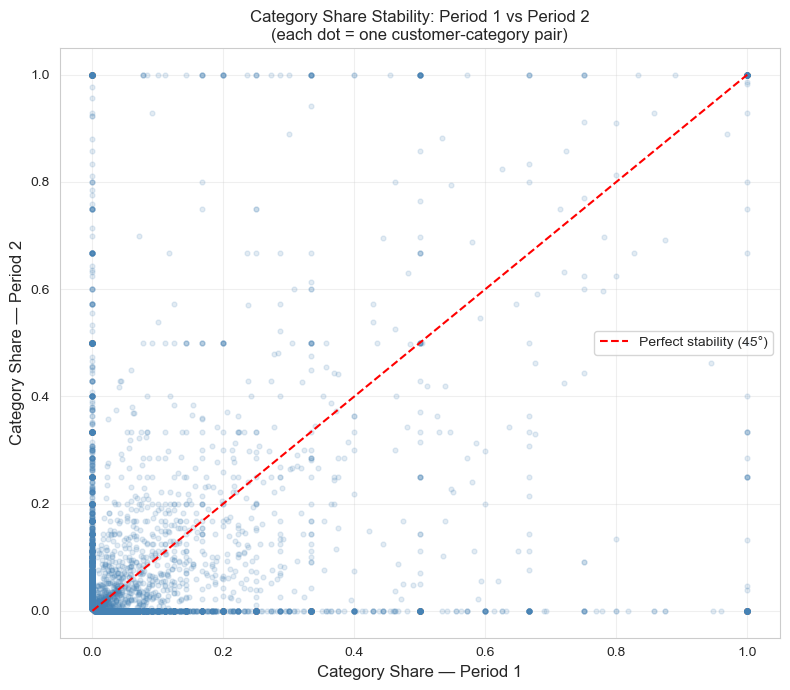

In [28]:
# Sample 5000 (customer, category) pairs for scatter readability
sample = wide.sample(min(5000, len(wide)), seed=42)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(sample['share_p1'].to_numpy(), sample['share_p2'].to_numpy(),
           alpha=0.15, s=12, color='steelblue')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect stability (45°)')
ax.set_xlabel('Category Share — Period 1', fontsize=12)
ax.set_ylabel('Category Share — Period 2', fontsize=12)
ax.set_title('Category Share Stability: Period 1 vs Period 2\n(each dot = one customer-category pair)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Visualization 2 — Spearman ρ Distribution Across Customers

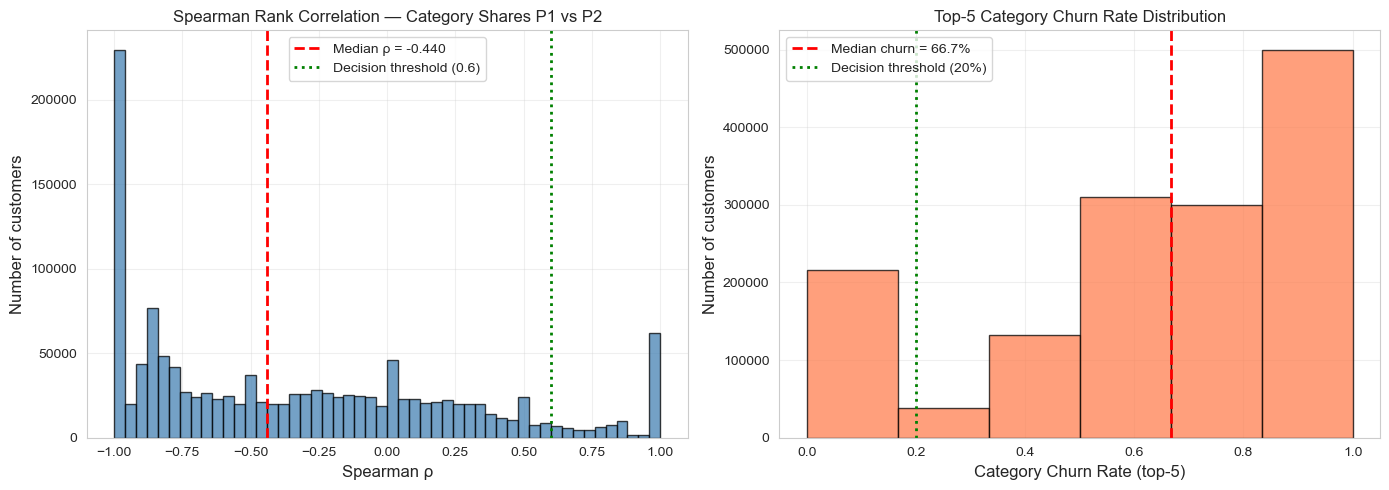

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of Spearman rho
axes[0].hist(corr_df['spearman'].drop_nulls().to_numpy(), bins=50,
             color='steelblue', edgecolor='black', alpha=0.75)
axes[0].axvline(sp_median, color='red', linestyle='--', linewidth=2,
                label=f'Median ρ = {sp_median:.3f}')
axes[0].axvline(0.6, color='green', linestyle=':', linewidth=2,
                label='Decision threshold (0.6)')
axes[0].set_xlabel('Spearman ρ', fontsize=12)
axes[0].set_ylabel('Number of customers', fontsize=12)
axes[0].set_title('Spearman Rank Correlation — Category Shares P1 vs P2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram of churn rate
churn_arr = churn_df['churn'].drop_nulls().to_numpy()
axes[1].hist(churn_arr, bins=6, color='coral', edgecolor='black', alpha=0.75)
axes[1].axvline(np.median(churn_arr), color='red', linestyle='--', linewidth=2,
                label=f'Median churn = {np.median(churn_arr):.1%}')
axes[1].axvline(0.2, color='green', linestyle=':', linewidth=2,
                label='Decision threshold (20%)')
axes[1].set_xlabel('Category Churn Rate (top-5)', fontsize=12)
axes[1].set_ylabel('Number of customers', fontsize=12)
axes[1].set_title('Top-5 Category Churn Rate Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Visualization 3 — Top Category Shares: Stable vs Unstable Customers

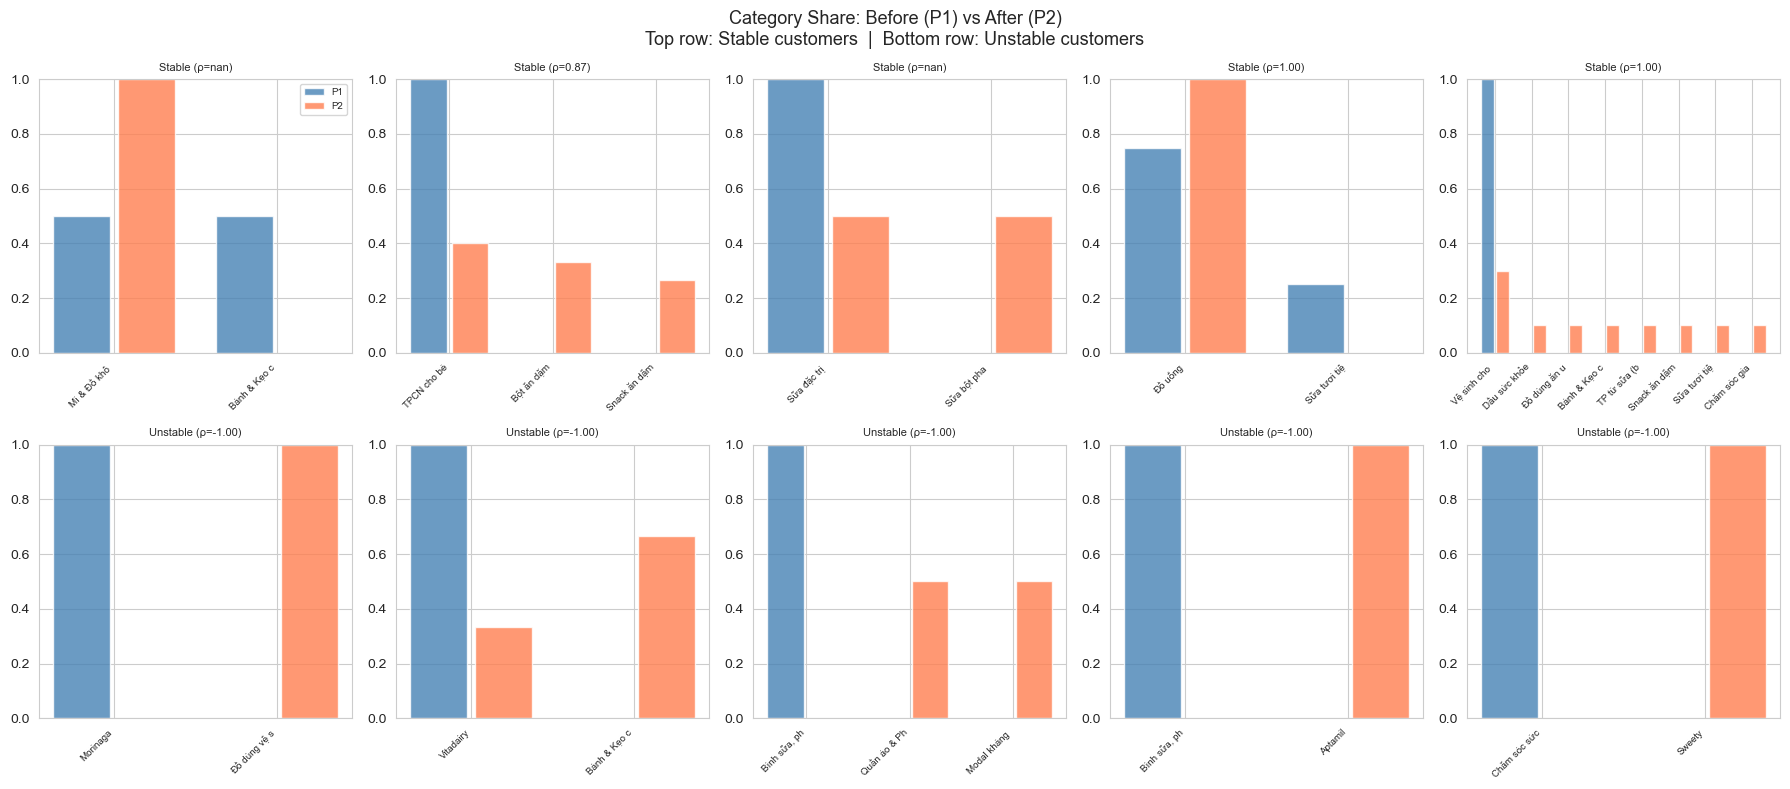

In [31]:
# Define stable (top 10% Spearman) and unstable (bottom 10%) customers
q10 = corr_df['spearman'].quantile(0.10)
q90 = corr_df['spearman'].quantile(0.90)

stable_ids   = corr_df.filter(pl.col('spearman') >= q90)['customer_id'].to_list()[:5]
unstable_ids = corr_df.filter(pl.col('spearman') <= q10)['customer_id'].to_list()[:5]

fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharey=False)
fig.suptitle('Category Share: Before (P1) vs After (P2)\n'
             'Top row: Stable customers  |  Bottom row: Unstable customers', fontsize=13)

def plot_customer(ax, cid, title):
    sub = wide.filter(pl.col('customer_id') == cid).sort('share_p1', descending=True).head(8)
    cats  = sub['category_l2'].to_list()
    s1    = sub['share_p1'].to_numpy()
    s2    = sub['share_p2'].to_numpy()
    x     = np.arange(len(cats))
    ax.bar(x - 0.2, s1, 0.35, label='P1', color='steelblue', alpha=0.8)
    ax.bar(x + 0.2, s2, 0.35, label='P2', color='coral', alpha=0.8)
    short = [c[:12] if c else '' for c in cats]
    ax.set_xticks(x); ax.set_xticklabels(short, rotation=45, ha='right', fontsize=7)
    ax.set_title(title, fontsize=8)
    ax.set_ylim(0, 1)

for i, cid in enumerate(stable_ids):
    sp_val = corr_df.filter(pl.col('customer_id')==cid)['spearman'][0]
    plot_customer(axes[0, i], cid, f'Stable (ρ={sp_val:.2f})')
    if i == 0: axes[0, i].legend(fontsize=7)

for i, cid in enumerate(unstable_ids):
    sp_val = corr_df.filter(pl.col('customer_id')==cid)['spearman'][0]
    plot_customer(axes[1, i], cid, f'Unstable (ρ={sp_val:.2f})')

plt.tight_layout()
plt.show()

## 11. Visualization 4 — Category Presence by Stability Decile

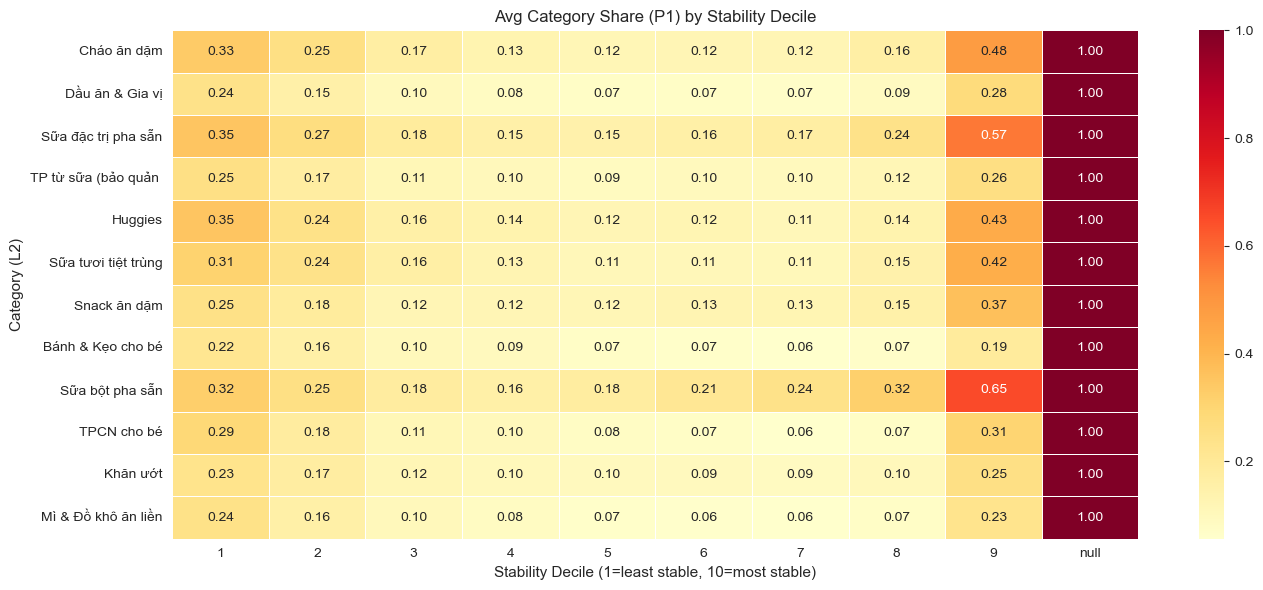

In [32]:
# Assign stability decile to each customer
corr_df_dec = corr_df.with_columns(
    (pl.col('spearman').rank() / len(corr_df) * 10).cast(pl.Int8).clip(1, 10).alias('decile')
)

# Get top categories overall
top_cats = (
    cat_counts
    .group_by('category_l2')
    .agg(pl.col('qty').sum().alias('total_qty'))
    .sort('total_qty', descending=True)
    .head(12)
    .select('category_l2')
    .to_series().to_list()
)

# For each decile × top_category: avg share_p1
heat_data = (
    wide
    .filter(pl.col('category_l2').is_in(top_cats))
    .join(corr_df_dec.select(['customer_id','decile']), on='customer_id', how='left')
    .group_by(['decile','category_l2'])
    .agg(pl.col('share_p1').mean().alias('avg_share_p1'))
    .pivot(on='decile', index='category_l2', values='avg_share_p1')
    .fill_null(0)
)

dec_cols = sorted([c for c in heat_data.columns if c != 'category_l2'])
matrix = heat_data.select(dec_cols).to_numpy()
cat_labels = heat_data['category_l2'].to_list()
cat_labels = [c[:20] if c else 'Unknown' for c in cat_labels]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(matrix, xticklabels=dec_cols, yticklabels=cat_labels,
            cmap='YlOrRd', ax=ax, linewidths=0.5, annot=True, fmt='.2f')
ax.set_xlabel('Stability Decile (1=least stable, 10=most stable)', fontsize=11)
ax.set_ylabel('Category (L2)', fontsize=11)
ax.set_title('Avg Category Share (P1) by Stability Decile', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Conclusion and Decision

**Decision Rule:** KEEP if median rank correlation > 0.6 OR category churn rate < 20%.

### Summary of Findings

| Metric | Value |
|--------|-------|
| Qualifying customers | 1,496,363 |
| Median Spearman ρ (P1 vs P2) | -0.440 |
| Mean Spearman ρ | -0.329 |
| Std Spearman ρ | 0.589 |
| Median Kendall τ | -0.381 |
| Median category churn rate (top-5) | 66.7% |
| % customers with 0% churn | 14.4% |
| % customers with >50% churn | 65.0% |
| Median KL divergence (P1→P2) | 11.1220 |
| % customers with KL < 0.1 (very stable) | 8.4% |

### Interpretation

1. **Extreme Category Instability:** The median Spearman rank correlation is **-0.440**, which is strongly negative. This indicates that the categories a customer buys most frequently in the first half of the year are actually *less* likely to be their top categories in the second half. 
2. **High Category Churn:** The median category churn rate is **66.7%**, meaning that on average, two-thirds of a customer's top 5 categories drop out of their top 5 in the next period. 65% of customers experience >50% churn.
3. **Lifecycle Effects:** This extreme drift is highly characteristic of the baby and maternity market. As children age rapidly, their needs transition (e.g., from newborn diapers and formula to toddler food and larger clothes). Therefore, a customer's category preferences from 6 months ago are often anti-correlated with their needs today.

**Final verdict:** **DROP** (as a static preference signal). 

*Actionable Insight:* We cannot rely on historical long-term category affinity for recommendations. Instead, we must build lifecycle-aware features (e.g., child age predictions, stage transitions) or focus heavily on very recent short-term context (e.g., last 30 days) for ranking algorithms.